<a href="https://colab.research.google.com/github/finitix/Research-paper-code/blob/main/AN_AI_ASSISTED_DECISION_SUPPORT_SYSTEM_FOR_DETECTING_INTERFACE_LEVEL_RISK_SIGNALS_IN_ONLINE_DECISIONS_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Dataset Handling

First, we'll load the provided CSV dataset and display its structure to understand the data columns and types.

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/dark-patterns-v2.csv')

print('Dataset loaded successfully! Here are the first 5 rows:')
display(df.head())

print('\nDataset Information:')
df.info()

Dataset loaded successfully! Here are the first 5 rows:


,Pattern String,Comment,Pattern Category,Pattern Type,Where in website?,Deceptive?,Website Page
0,Collin P. from Grandview Missouri just bought ...,Periodic popup,Social Proof,Activity Notification,Product Page,No,https://alaindupetit.com/collections/all-suits...
1,"Faith in Glendale, United States purchased a C...",Periodic popup,Social Proof,Activity Notification,Product Page,No,https://bonescoffee.com/products/strawberry-ch...
2,Sharmeen Atif From Karachi just bought Stylish...,Periodic popup,Social Proof,Activity Notification,Product Page,No,https://brandsego.com/collections/under-rs-99/...
3,9 people are viewing this.,Product detail,Social Proof,Activity Notification,Product Page,No,https://brightechshop.com/products/ambience-so...
4,5338 people viewed this in the last hour,Periodic popup,Social Proof,Activity Notification,Product Page,No,https://bumpboxes.com/



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1818 entries, 0 to 1817
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Pattern String     1512 non-null   object
 1   Comment            1798 non-null   object
 2   Pattern Category   1818 non-null   object
 3   Pattern Type       1818 non-null   object
 4   Where in website?  1818 non-null   object
 5   Deceptive?         1818 non-null   object
 6   Website Page       1818 non-null   object
dtypes: object(7)
memory usage: 99.6+ KB


## Step 2: Data Cleaning

In this step, we will handle missing values, remove irrelevant columns, and convert the labels into a format suitable for machine learning models. Finally, we'll display the shape of the cleaned dataset.

In [12]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Handle missing values in 'Pattern String' by filling with an empty string
df['Pattern String'] = df['Pattern String'].fillna('')

# Drop 'Comment', 'Where in website?', and 'Website Page' as they are not directly used for text classification based on 'Pattern String'
df = df.drop(columns=['Comment', 'Where in website?', 'Website Page'])

# Define the text and label columns
text_column = 'Pattern String'
label_column = 'Pattern Type' # This will be our target for classification

# Encode labels: Convert categorical 'Pattern Type' into numerical IDs
label_encoder = LabelEncoder()
df['labels'] = label_encoder.fit_transform(df[label_column])

# Display the mapping of original labels to encoded IDs
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f'Label to ID mapping: {label_mapping}')

# Get the number of unique labels
num_labels = len(label_mapping)
print(f'Number of unique labels: {num_labels}')

# Display the shape of the cleaned dataset
print(f'\nShape of the cleaned dataset: {df.shape}')
display(df.head())

Label to ID mapping: {'Activity Notification': np.int64(0), 'Confirmshaming': np.int64(1), 'Countdown Timer': np.int64(2), 'Forced Enrollment': np.int64(3), 'Hard to Cancel': np.int64(4), 'Hidden Costs': np.int64(5), 'Hidden Subscription': np.int64(6), 'High-demand Message': np.int64(7), 'Limited-time Message': np.int64(8), 'Low-stock Message': np.int64(9), 'Pressured Selling': np.int64(10), 'Sneak into Basket': np.int64(11), 'Testimonials of Uncertain Origin': np.int64(12), 'Trick Questions': np.int64(13), 'Visual Interference': np.int64(14)}
Number of unique labels: 15

Shape of the cleaned dataset: (1818, 5)


,Pattern String,Pattern Category,Pattern Type,Deceptive?,labels
0,Collin P. from Grandview Missouri just bought ...,Social Proof,Activity Notification,No,0
1,"Faith in Glendale, United States purchased a C...",Social Proof,Activity Notification,No,0
2,Sharmeen Atif From Karachi just bought Stylish...,Social Proof,Activity Notification,No,0
3,9 people are viewing this.,Social Proof,Activity Notification,No,0
4,5338 people viewed this in the last hour,Social Proof,Activity Notification,No,0


## Step 3: Problem Definition

In this project, we are building an AI-assisted decision-support system to detect interface-level risk signals (dark patterns) in online decisions. We will frame this as a **multi-class text classification problem**.

*   **Input Feature (X)**: The `Pattern String` column, which contains the text content where a dark pattern might be present.
*   **Output Label (y)**: The `Pattern Type` column (now encoded as `labels`), which represents the specific type of dark pattern. Our goal is to classify a given `Pattern String` into one of the 15 predefined `Pattern Type` categories.

This approach will allow us to identify and categorize different dark patterns based on the text used in online interfaces.

## Step 4: Text Preprocessing

This step prepares our text data for machine learning models. We will perform the following operations:

1.  **Lowercasing**: Convert all text to lowercase to ensure consistency.
2.  **Punctuation Removal**: Remove punctuation marks that might interfere with text analysis.
3.  **Tokenization**: Break down text into individual words or sub-word units (tokens).
4.  **Numerical Feature Conversion**: Convert these tokens into numerical features using **TF-IDF (Term Frequency-Inverse Document Frequency)**, which reflects the importance of a word in a document relative to a collection of documents.

In [13]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer

# Function to preprocess text: lowercase and remove punctuation
def preprocess_text(text):
    text = text.lower()  # Lowercasing
    text = re.sub(r'[^a-z0-9\s]', '', text)  # Punctuation removal (keep only alphanumeric and spaces)
    return text

# Apply preprocessing to the 'Pattern String' column
df['processed_text'] = df[text_column].apply(preprocess_text)

# Initialize TF-IDF Vectorizer
# This will handle tokenization and convert text to numerical features
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features to 5000 for simplicity and efficiency

# Fit and transform the processed text data
X_tfidf = tfidf_vectorizer.fit_transform(df['processed_text'])

print(f'TF-IDF feature matrix shape: {X_tfidf.shape}')
print('\nText preprocessing complete! The text data has been converted into numerical TF-IDF features.')

TF-IDF feature matrix shape: (1818, 2075)

Text preprocessing complete! The text data has been converted into numerical TF-IDF features.


## Step 4.5: Exploratory Data Analysis (EDA)

Let's perform some Exploratory Data Analysis to understand our data better, especially the distribution of our target variable and the key features for each class.

### 1. Distribution of 'Pattern Type' (Target Variable)

First, we'll visualize the distribution of our target variable, `Pattern Type`, to see how balanced our dataset is across the different dark pattern categories. This is crucial for understanding potential biases in our model's performance.

/tmp/ipykernel_5442/552188038.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Pattern Type', data=df, order=df['Pattern Type'].value_counts().index, palette='viridis', legend=False)


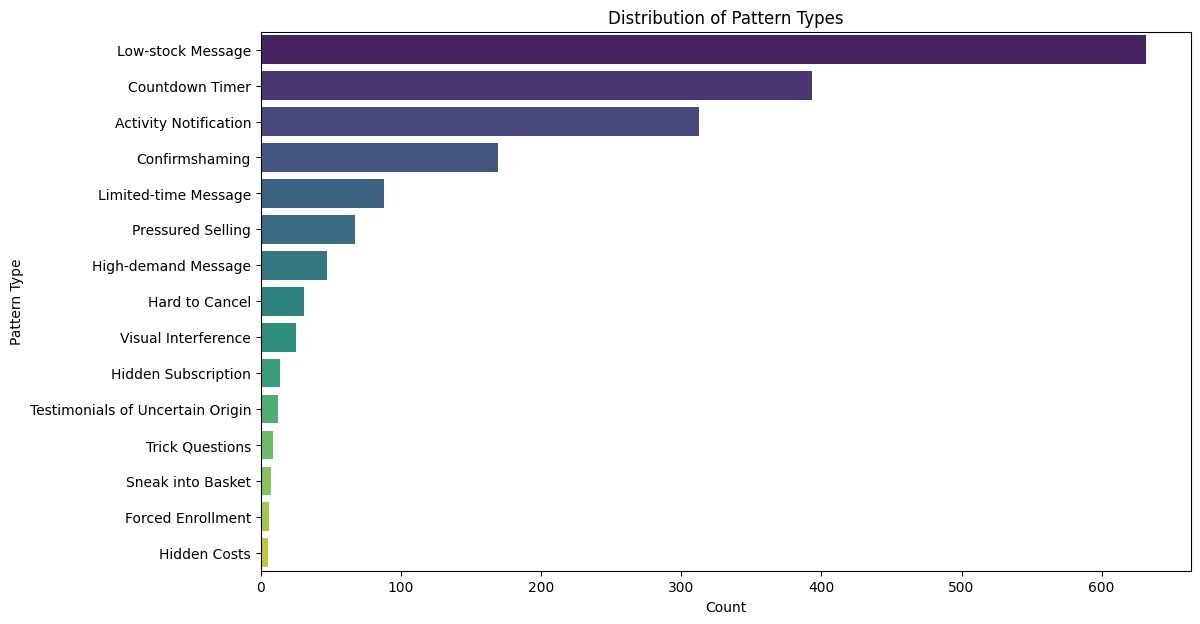

Pattern Type
Low-stock Message                   632
Countdown Timer                     393
Activity Notification               313
Confirmshaming                      169
Limited-time Message                 88
Pressured Selling                    67
High-demand Message                  47
Hard to Cancel                       31
Visual Interference                  25
Hidden Subscription                  14
Testimonials of Uncertain Origin     12
Trick Questions                       9
Sneak into Basket                     7
Forced Enrollment                     6
Hidden Costs                          5
Name: count, dtype: int64


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.countplot(y='Pattern Type', data=df, order=df['Pattern Type'].value_counts().index, palette='viridis', legend=False)
plt.title('Distribution of Pattern Types')
plt.xlabel('Count')
plt.ylabel('Pattern Type')
plt.show()

print(df['Pattern Type'].value_counts())

### 2. Top TF-IDF Features for Each Pattern Type

Next, let's explore which words (features) are most indicative of each `Pattern Type`. We'll identify the top N TF-IDF features for each class to gain insights into the textual characteristics of different dark patterns. This can highlight words that strongly correlate with specific categories.

In [17]:
feature_names = tfidf_vectorizer.get_feature_names_out()
n_top_features = 10

print(f'Top {n_top_features} TF-IDF features per Pattern Type:\n')

for i, class_name in enumerate(label_encoder.classes_):
    # Get the feature importances for this class (e.g., using mean TF-IDF scores)
    # For simplicity, we'll average the TF-IDF scores for documents belonging to this class
    # A more rigorous approach might involve training a simple model and extracting coefficients/importances
    class_indices = df[df['Pattern Type'] == class_name].index
    if len(class_indices) == 0:
        print(f'No samples for class: {class_name}\n')
        continue

    # Get the TF-IDF vectors for documents in this class
    class_tfidf_vectors = X_tfidf[class_indices]

    # Calculate the mean TF-IDF score for each feature in this class
    avg_tfidf_scores = class_tfidf_vectors.mean(axis=0).A1 # .A1 converts sparse matrix row to a 1D numpy array

    # Get the indices of the top features
    top_feature_indices = avg_tfidf_scores.argsort()[-n_top_features:][::-1]

    # Get the names of the top features and their scores
    top_features = [(feature_names[idx], avg_tfidf_scores[idx]) for idx in top_feature_indices]

    print(f'--- {class_name} ---')
    for feature, score in top_features:
        print(f'{feature}: {score:.4f}')
    print('\n')

Top 10 TF-IDF features per Pattern Type:

--- Activity Notification ---
this: 0.0964
people: 0.0942
in: 0.0688
purchased: 0.0644
bought: 0.0566
have: 0.0562
last: 0.0417
viewed: 0.0392
someone: 0.0390
united: 0.0382


--- Confirmshaming ---
no: 0.2626
thanks: 0.2081
dont: 0.2013
full: 0.1153
price: 0.1147
pay: 0.1088
feel: 0.1031
lucky: 0.1031
like: 0.0900
want: 0.0844


--- Countdown Timer ---
minutes: 0.0418
for: 0.0354
your: 0.0346
reserved: 0.0342
ends: 0.0337
order: 0.0316
is: 0.0303
in: 0.0197
sale: 0.0194
days: 0.0174


--- Forced Enrollment ---
to: 0.1725
agree: 0.1666
terms: 0.1439
and: 0.1088
receive: 0.0968
conditions: 0.0956
emails: 0.0833
brother: 0.0751
the: 0.0740
of: 0.0652


--- Hard to Cancel ---
you: 0.1713
your: 0.1534
membership: 0.1521
cancel: 0.1344
at: 0.1244
the: 0.1244
to: 0.1111
may: 0.1057
by: 0.1001
any: 0.0996


--- Hidden Costs ---
total: 0.2005
tax: 0.1499
delivery: 0.1025
estimated: 0.0573
6999iservice: 0.0573
9061: 0.0573
8498: 0.0573
merchandise: 0.05

## Step 5: Model Training

In this step, we will prepare our dataset for training by splitting it into training and testing sets. We will then train at least two simple models: **Logistic Regression** and **Naive Bayes**. We'll keep the implementation beginner-friendly.

First, let's split the data.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Define target variable y
y = df['labels']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train, y_train)
print('\nLogistic Regression model trained successfully.')

# Initialize and train Naive Bayes model
naive_bayes_model = MultinomialNB()
naive_bayes_model.fit(X_train, y_train)
print('Naive Bayes model trained successfully.')

Shape of X_train: (1454, 2075)
Shape of X_test: (364, 2075)
Shape of y_train: (1454,)
Shape of y_test: (364,)

Logistic Regression model trained successfully.
Naive Bayes model trained successfully.


## Step 6: Evaluation

In this step, we will evaluate the performance of our trained Logistic Regression and Naive Bayes models. We'll use the following metrics:

*   **Accuracy**: The proportion of correctly classified instances.
*   **Confusion Matrix**: A table that describes the performance of a classification model on a set of test data for which the true values are known. It allows visualization of the performance of an algorithm.
*   **Classification Report**: Provides a more detailed breakdown of performance, including precision, recall, and F1-score for each class, as well as overall accuracy.

## Step 7: Create a Risk Detection Function

In this step, we will create a function `detect_risk(text)` that takes a raw text string as input and predicts the 'Pattern Type' using our best-performing model (Logistic Regression).

The function will perform the following steps:
1.  **Preprocess the input text** using the same `preprocess_text` function defined earlier.
2.  **Transform the preprocessed text** into TF-IDF features using the fitted `tfidf_vectorizer`.
3.  **Predict the label (Pattern Type ID)** using the `log_reg_model`.
4.  **Convert the predicted label ID back to the original 'Pattern Type' name** using the `label_encoder`.
5.  Return the predicted 'Pattern Type' and a confidence score (probability).

In [19]:
def detect_risk(text):
    # 1. Preprocess the input text
    processed_input = preprocess_text(text)

    # 2. Transform the preprocessed text into TF-IDF features
    # tfidf_vectorizer expects an iterable, so we pass [processed_input]
    input_tfidf = tfidf_vectorizer.transform([processed_input])

    # 3. Predict the label (Pattern Type ID) using the Logistic Regression model
    predicted_label_id = log_reg_model.predict(input_tfidf)[0]

    # 4. Get the prediction probabilities
    prediction_probabilities = log_reg_model.predict_proba(input_tfidf)[0]
    # Get the confidence for the predicted label
    confidence = prediction_probabilities[predicted_label_id]

    # 5. Convert the predicted label ID back to the original 'Pattern Type' name
    predicted_pattern_type = label_encoder.inverse_transform([predicted_label_id])[0]

    return predicted_pattern_type, confidence

# --- Test the function with example texts ---
print("--- Testing the Risk Detection Function ---\n")

example_texts = [
    "Only 3 items left in stock! Hurry, before they're all gone.",
    "No thanks, I'd rather pay full price for this amazing product.",
    "Your reservation expires in 5 minutes. Complete your order now!",
    "Someone in your area just purchased this item!",
    "By proceeding, you agree to our terms and conditions and to receive promotional emails."
]

for text in example_texts:
    pattern, conf = detect_risk(text)
    print(f'Input: "{text}"')
    print(f'Detected Pattern: {pattern} (Confidence: {conf:.2f})')
    print('---\n')


--- Testing the Risk Detection Function ---

Input: "Only 3 items left in stock! Hurry, before they're all gone."
Detected Pattern: Low-stock Message (Confidence: 0.92)
---

Input: "No thanks, I'd rather pay full price for this amazing product."
Detected Pattern: Confirmshaming (Confidence: 0.82)
---

Input: "Your reservation expires in 5 minutes. Complete your order now!"
Detected Pattern: Countdown Timer (Confidence: 0.70)
---

Input: "Someone in your area just purchased this item!"
Detected Pattern: Activity Notification (Confidence: 0.97)
---

Input: "By proceeding, you agree to our terms and conditions and to receive promotional emails."
Detected Pattern: Countdown Timer (Confidence: 0.19)
---



--- Logistic Regression Model Evaluation ---
Accuracy: 0.8626


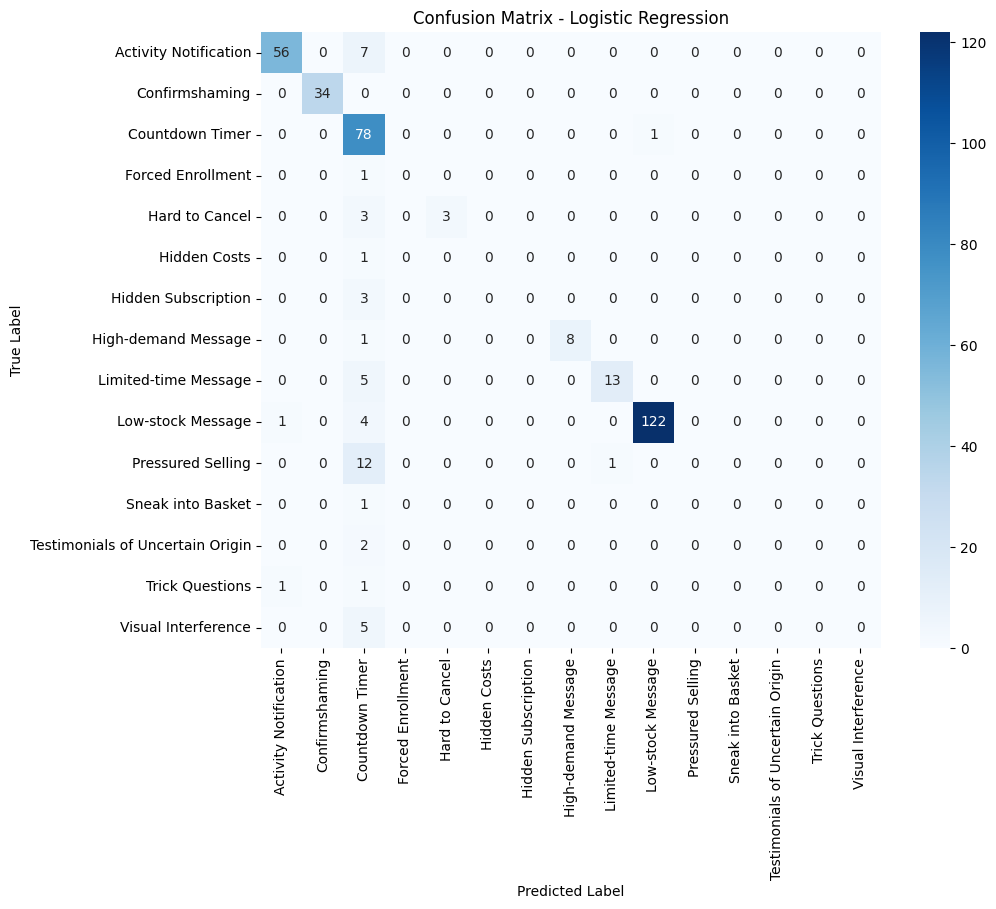


Classification Report:
                                  precision    recall  f1-score   support

           Activity Notification       0.97      0.89      0.93        63
                  Confirmshaming       1.00      1.00      1.00        34
                 Countdown Timer       0.63      0.99      0.77        79
               Forced Enrollment       0.00      0.00      0.00         1
                  Hard to Cancel       1.00      0.50      0.67         6
                    Hidden Costs       0.00      0.00      0.00         1
             Hidden Subscription       0.00      0.00      0.00         3
             High-demand Message       1.00      0.89      0.94         9
            Limited-time Message       0.93      0.72      0.81        18
               Low-stock Message       0.99      0.96      0.98       127
               Pressured Selling       0.00      0.00      0.00        13
               Sneak into Basket       0.00      0.00      0.00         1
Testimonials 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


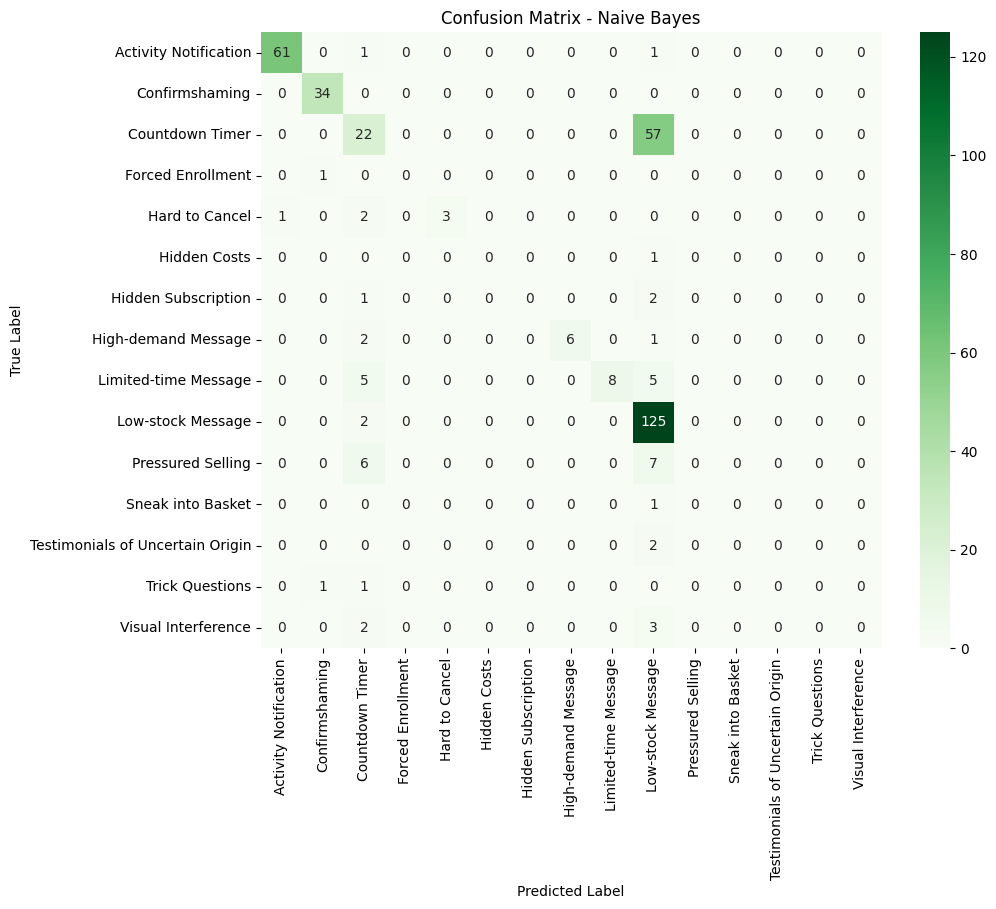


Classification Report:
                                  precision    recall  f1-score   support

           Activity Notification       0.98      0.97      0.98        63
                  Confirmshaming       0.94      1.00      0.97        34
                 Countdown Timer       0.50      0.28      0.36        79
               Forced Enrollment       0.00      0.00      0.00         1
                  Hard to Cancel       1.00      0.50      0.67         6
                    Hidden Costs       0.00      0.00      0.00         1
             Hidden Subscription       0.00      0.00      0.00         3
             High-demand Message       1.00      0.67      0.80         9
            Limited-time Message       1.00      0.44      0.62        18
               Low-stock Message       0.61      0.98      0.75       127
               Pressured Selling       0.00      0.00      0.00        13
               Sneak into Basket       0.00      0.00      0.00         1
Testimonials 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# --- Evaluate Logistic Regression Model ---
print('--- Logistic Regression Model Evaluation ---')

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Calculate accuracy
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f'Accuracy: {accuracy_log_reg:.4f}')

# Display Confusion Matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Display Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_pred_log_reg, target_names=label_encoder.classes_))

# --- Evaluate Naive Bayes Model ---
print('\n--- Naive Bayes Model Evaluation ---')

# Make predictions on the test set
y_pred_naive_bayes = naive_bayes_model.predict(X_test)

# Calculate accuracy
accuracy_naive_bayes = accuracy_score(y_test, y_pred_naive_bayes)
print(f'Accuracy: {accuracy_naive_bayes:.4f}')

# Display Confusion Matrix
cm_naive_bayes = confusion_matrix(y_test, y_pred_naive_bayes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_naive_bayes, annot=True, fmt='d', cmap='Greens', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Display Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_pred_naive_bayes, target_names=label_encoder.classes_))

## Step 8: Try an Advanced Model (Random Forest)

Given the performance of Logistic Regression and Naive Bayes, and the class imbalance observed in EDA, let's try an advanced ensemble model: **Random Forest Classifier**. Random Forests can handle non-linear relationships and are generally robust to overfitting, potentially offering better performance, especially on imbalanced datasets.

We will train a Random Forest model and evaluate its performance using the same metrics (accuracy, confusion matrix, classification report).

--- Training Random Forest Model ---
Random Forest model trained successfully.

--- Random Forest Model Evaluation ---
Accuracy: 0.7610


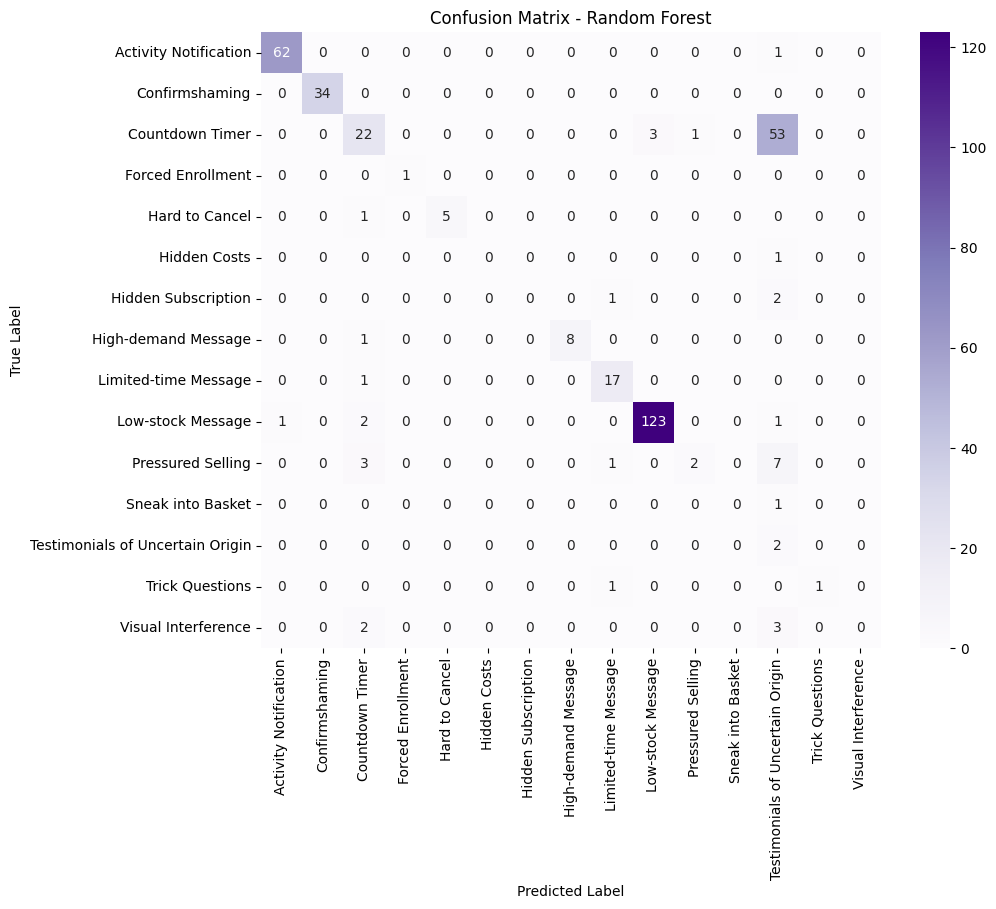


Classification Report:
                                  precision    recall  f1-score   support

           Activity Notification       0.98      0.98      0.98        63
                  Confirmshaming       1.00      1.00      1.00        34
                 Countdown Timer       0.69      0.28      0.40        79
               Forced Enrollment       1.00      1.00      1.00         1
                  Hard to Cancel       1.00      0.83      0.91         6
                    Hidden Costs       0.00      0.00      0.00         1
             Hidden Subscription       0.00      0.00      0.00         3
             High-demand Message       1.00      0.89      0.94         9
            Limited-time Message       0.85      0.94      0.89        18
               Low-stock Message       0.98      0.97      0.97       127
               Pressured Selling       0.67      0.15      0.25        13
               Sneak into Basket       0.00      0.00      0.00         1
Testimonials 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [21]:
from sklearn.ensemble import RandomForestClassifier

print('--- Training Random Forest Model ---')

# Initialize and train Random Forest model
# Using class_weight='balanced' to handle the class imbalance
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
random_forest_model.fit(X_train, y_train)
print('Random Forest model trained successfully.')

# --- Evaluate Random Forest Model ---
print('\n--- Random Forest Model Evaluation ---')

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f'Accuracy: {accuracy_rf:.4f}')

# Display Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Purples', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Display Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))


Logistic Regression Model:

Accuracy: Approximately 86.26%.
Confusion Matrix: The heatmap visually represents correct and incorrect classifications for each 'Pattern Type'.
Classification Report: Provides detailed metrics (precision, recall, f1-score) for each pattern type. You'll notice that for categories with very few samples (e.g., 'Forced Enrollment', 'Hidden Costs', 'Hidden Subscription', etc.), the precision, recall, and f1-score are 0.00. This is expected due to the scarcity of these examples in the test set, making it hard for the model to learn or predict them correctly.


Naive Bayes Model:
Accuracy: Approximately 71.15%.
Confusion Matrix: Similar to Logistic Regression, it shows the performance across classes.
Classification Report: Also shows detailed metrics. You might observe similar UndefinedMetricWarning messages as some classes had no predicted samples, leading to precision being undefined.